# 📘 Tutorial 2: Standard Acquisition Functions in BoTorch

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 1**, we learned how to build, fit, and query Gaussian Process surrogates in BoTorch.

That gave us the core modelling ingredients of Bayesian Optimisation:

- a posterior mean `μ(x)` that represents the model’s current best estimate of the objective,
- and a posterior standard deviation `σ(x)` that quantifies predictive uncertainty.

In this tutorial, we take the next conceptual step:

> **given a fitted BoTorch GP surrogate, how should we choose where to evaluate next?**

This is the role of an **acquisition function**.

The Gaussian Process tells us what the model currently believes.
The acquisition function turns that belief into a **decision rule**.

We will focus on three standard acquisition functions:

- **Upper Confidence Bound (UCB)**
- **Probability of Improvement (PI)**
- **Log Expected Improvement (LogEI)**

These are not new ideas in themselves — they were already introduced conceptually in **Part 3**.
What is new here is that we will now implement them directly in **BoTorch**, visualise them as one-dimensional scoring rules, optimise them numerically, and compare the candidate points they recommend.

---

**This tutorial is designed to shift perspective**
- from *“I understand acquisition functions mathematically”*
- to *“I can now instantiate, evaluate, optimise, and compare them in BoTorch.”*

---

**The emphasis is on developing intuition for**
- why BoTorch acquisition functions are typically written for maximisation,
- how minimisation problems are converted into a compatible form,
- how acquisition landscapes can be visualised directly in one dimension,
- how `optimize_acqf` turns a scoring rule into an actual candidate point,
- and how different acquisition choices lead to different posterior updates.

---

**Key ideas explored include**
- recasting minimisation as maximisation through `-f(x)`,
- standard analytic acquisition functions in BoTorch,
- numerical optimisation of acquisition functions,
- comparing UCB, PI, and LogEI on the same surrogate,
- one-step posterior updates after different acquisition choices,
- and wrapping the workflow into a reusable acquisition-step function.

---

This tutorial serves as the practical bridge between:

- the **GP surrogate modelling** of Tutorial 1,
- and the **full sequential Bayesian Optimisation loop** that will appear next.

In other words, Tutorial 1 taught us how to build the surrogate.
Tutorial 2 teaches us how to act on it.

---

**Recommended prerequisites**
- Completion of **Tutorial 1**
- Familiarity with Gaussian Process posterior mean and uncertainty
- Basic understanding of PI, EI, and UCB from **Part 3**
- Comfort with one-dimensional plotting and BoTorch GP models

---

**Author**: Angze Li

**Last updated**: 2026-04-06

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.posteriors import GPyTorchPosterior
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.set_default_dtype(torch.double)
torch.manual_seed(0)


def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

## 1. A one-dimensional objective for studying acquisition functions

To study acquisition functions clearly, we begin with a **one-dimensional objective** that is rich enough to produce nontrivial Gaussian Process behaviour, but still simple enough to visualise directly.

This is important because, in this tutorial, we want to see not only the fitted GP surrogate, but also how different acquisition rules respond to:

- multiple promising regions,
- sparse observations,
- and varying uncertainty across the domain.

---

### What the code does

The function `objective_1d(x)` defines a structured one-dimensional objective made from several components:

- multiple negative Gaussian-shaped dips,
- oscillatory terms at different frequencies,
- a mild quadratic trend,
- and a tangent-based deformation that introduces additional asymmetry.

Together, these produce a function with:

- more than one locally attractive region,
- both broad and narrow features,
- and enough irregularity that different acquisition functions do not have to agree automatically.

The code then constructs a dense grid

$$
x_{\text{dense}} \in [-3,\;3],
$$

and evaluates the objective on that grid to obtain `y_dense`.

Finally, it defines a set of observed training points `train_X`, evaluates the objective there, and adds a small perturbation to create noisy observations `train_Y`.

---

### Why this objective is a good choice here

This function is deliberately more structured than the one used in the previous tutorial.

That is useful because the main goal of Tutorial 2 is **not just to fit a GP**, but to examine how acquisition functions behave once a surrogate has been fitted.

If the objective were too simple, then many acquisition rules would tend to select nearly the same next point, and the comparison would be less informative.

By contrast, this objective contains:

- competing local low-value regions,
- local oscillatory structure,
- and uneven difficulty across the domain.

That makes it much better suited for showing how different acquisition functions can prefer different next evaluations even when they are built from the same GP posterior.

---

### Why the printed shapes matter

The printed output confirms that:

- `train_X` has shape `(10, 1)`
- `train_Y` has shape `(10, 1)`

This matches the standard BoTorch convention

$$
\text{train\_X} \in \mathbb{R}^{n \times d},
\qquad
\text{train\_Y} \in \mathbb{R}^{n \times m},
$$

where:

- **$n$** is the number of observations,
- **$d$** is the input dimension,
- **$m$** is the output dimension.

Here, we have:

- **$n = 10$**
- **$d = 1$**
- **$m = 1$**

So this cell is also setting up the data in exactly the form BoTorch needs for GP modelling.

---

### How to read the figure

The figure overlays:

- the **true objective** as a smooth curve,
- and the **observed training points** as scattered markers.

This immediately shows the central situation of the tutorial:

- the objective has substantial structure across the domain,
- but the surrogate will only be given a **small number of noisy observations**,
- so the Gaussian Process must infer the broader function from limited evidence.

This is precisely the setting in which acquisition functions become meaningful.
If the function were fully known, there would be no need for a surrogate and no need to decide where information is most valuable next.

The figure therefore serves two purposes at once:

- it shows the complexity of the underlying objective,
- and it shows the sparsity of the data support that the GP will actually receive.

So before any acquisition function is defined, the reader can already see why different rules might disagree about the next best point to evaluate.

---

### Key takeaway

This cell defines the one-dimensional objective used throughout Tutorial 2 and constructs the sparse noisy dataset that the BoTorch surrogate will be trained on.

The objective is intentionally rich enough to make acquisition-function behaviour genuinely interesting, while still remaining simple enough to visualise directly in one dimension.

train_X shape: (10, 1)
train_Y shape: (10, 1)


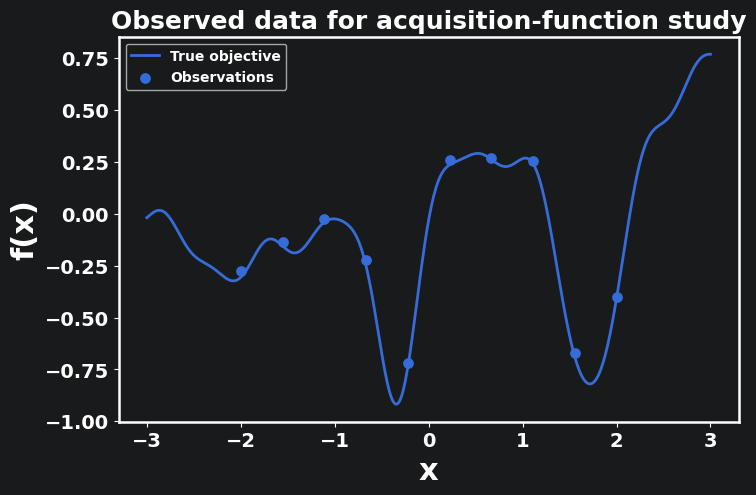

In [2]:
def objective_1d(x):
    return (
        -0.48 * torch.exp(-0.5 * ((x + 1.9) / 0.55) ** 2)
        -0.89 * torch.exp(-0.5 * ((x + 0.35) / 0.22) ** 2)
        -1.05 * torch.exp(-0.5 * ((x - 1.75) / 0.30) ** 2)
        +0.10 * torch.sin(2.8 * x)
        +0.06 * torch.sin(6.5 * x + 0.4)
        +0.035 * torch.cos(11.0 * x)
        +0.24 * torch.tan(0.3 * x)
        +0.025 * (x - 0.4) ** 2
        +0.16
    )
x_dense = torch.linspace(-3.0, 3.0, 500).unsqueeze(-1)
y_dense = objective_1d(x_dense)

train_X = torch.linspace(-2, 2, 10).unsqueeze(-1)
train_Y = objective_1d(train_X) + 0.03 * torch.rand_like(train_X)

print("train_X shape:", tuple(train_X.shape))
print("train_Y shape:", tuple(train_Y.shape))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
ax.scatter(train_X.numpy(), train_Y.numpy(), s=45, zorder=3, label="Observations")
ax.set_title("Observed data for acquisition-function study", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 2. Fitting the BoTorch Gaussian Process surrogate

Now that the one-dimensional objective and the observed training data have been defined, we can build the **Gaussian Process surrogate** that will support the rest of the tutorial.

This is the same core modelling workflow introduced in Tutorial 1:

- construct a `SingleTaskGP`,
- define the exact marginal log likelihood,
- fit the model hyperparameters,
- switch to evaluation mode,
- query the posterior on a dense grid,
- and extract the posterior mean and uncertainty.

The difference is that, in this tutorial, the fitted surrogate is no longer the final goal.
It will soon become the **input to acquisition functions**.

---

### What the code does

The line `gp = SingleTaskGP(...)` creates a BoTorch Gaussian Process surrogate using:

- the observed input locations `train_X`,
- the observed outputs `train_Y`,
- `Normalize(d=1)` for internal input rescaling,
- and `Standardize(m=1)` for internal output scaling.

The next two lines

- `mll = ExactMarginalLogLikelihood(gp.likelihood, gp)`
- `fit_gpytorch_mll(mll)`

define and optimise the standard exact GP fitting objective.

So at this stage, the model learns its internal hyperparameters from the observed data.

After fitting, the code calls `gp.eval()` and then queries the posterior over the dense grid `x_dense` using

`posterior = gp.posterior(x_dense)`.

From this posterior object, the code extracts:

- `mu_gp`: the posterior mean
- `var_gp`: the posterior variance
- `sigma_gp`: the posterior standard deviation

Finally, it plots:

- the **true objective**,
- the **BoTorch GP posterior mean**,
- the uncertainty band
  $$
  \mu(x)\pm 2\sigma(x),
  $$
- and the **observed training points**.

---

### Why this figure is important here

Although the main topic of Tutorial 2 is acquisition functions, we still need to begin by visualising the fitted surrogate itself.

That is because every acquisition rule introduced later in the notebook will be built from this posterior.

So this figure establishes the two central ingredients that acquisition functions will use:

- **prediction**, through the posterior mean `μ(x)`
- **uncertainty**, through the posterior standard deviation `σ(x)`

Without these two quantities, there is no Bayesian Optimisation decision rule yet.

In that sense, this figure is the last purely modelling-focused step before the tutorial moves into next-point selection.

---

### How to read the figure

The **dashed curve** is the GP’s posterior mean.
It represents the model’s best estimate of the latent objective after conditioning on the observed data.

The **shaded band** represents the uncertainty region around that mean.
As in the previous tutorial, it is narrower where the model is more strongly supported by observations and wider where data support is weaker.

The **scatter points** are the observations the GP has seen directly.

So the figure answers the key question:

> given these sparse noisy observations, what does the fitted BoTorch surrogate currently believe about the objective?

That is exactly the information acquisition functions will act on.

---

### Why the surrogate matters before acquisition functions

Acquisition functions do not operate on the raw observations alone.

They operate on the **posterior distribution of the surrogate model**.

So before introducing rules such as:

- Probability of Improvement,
- Expected Improvement,
- or Upper Confidence Bound,

we need to make the GP’s current posterior visible.

This is why the surrogate plot belongs here even in an acquisition-focused tutorial:
it is the object from which all later decision rules are built.

---

### Connection to Tutorial 1

This cell should feel familiar from Tutorial 1.

The modelling pipeline is intentionally unchanged:

- define the GP surrogate,
- fit it,
- query the posterior,
- and plot `μ(x)` and `σ(x)`.

That continuity is important.

It shows that acquisition functions do not introduce a completely new modelling system.
Instead, they sit **on top of** the fitted BoTorch GP surrogate already developed in the previous tutorial.

So the conceptual transition is:

- **Tutorial 1:** how to build and interpret the surrogate
- **Tutorial 2:** how to use that surrogate to decide where to evaluate next

---

### Key takeaway

This cell fits the BoTorch Gaussian Process surrogate to the observed data and visualises its posterior mean and uncertainty.

That gives us the two fundamental ingredients for the rest of the notebook:

- a predictive estimate of the objective through `μ(x)`
- and a quantified measure of uncertainty through `σ(x)`

These are exactly the quantities that acquisition functions will use to rank candidate evaluation points.

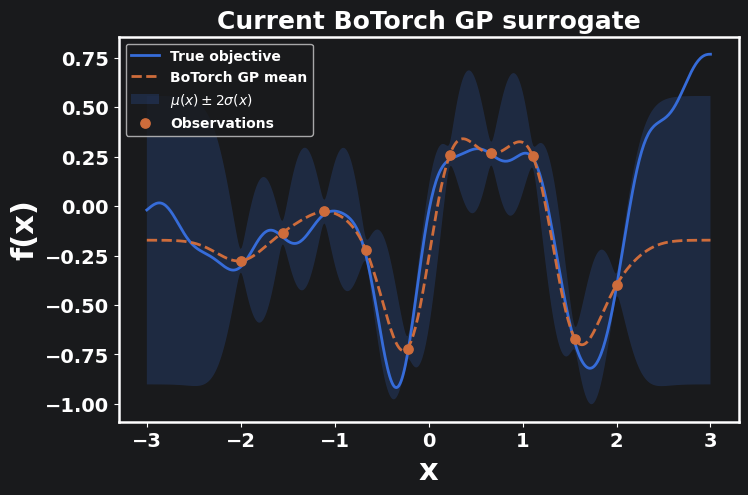

In [3]:
gp = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    input_transform=Normalize(d=1),
    outcome_transform=Standardize(m=1),
)

mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll)

gp.eval()
posterior = gp.posterior(x_dense)

mu_gp = posterior.mean.detach()
var_gp = posterior.variance.detach().clamp_min(1e-12)
sigma_gp = torch.sqrt(var_gp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
ax.plot(x_dense.numpy(), mu_gp.numpy(), linewidth=2.0, linestyle="--", label="BoTorch GP mean")
ax.fill_between(
    x_dense.squeeze(-1).numpy(),
    (mu_gp - 2.0 * sigma_gp).squeeze(-1).numpy(),
    (mu_gp + 2.0 * sigma_gp).squeeze(-1).numpy(),
    alpha=0.2,
    label=r"$\mu(x)\pm 2\sigma(x)$",
)
ax.scatter(train_X.numpy(), train_Y.numpy(), s=45, zorder=3, label="Observations")
ax.set_title("Current BoTorch GP surrogate", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"}, loc="upper left")
style_ax(ax)
plt.show()

## 3. Recasting the problem for BoTorch acquisition functions

At this point, the Gaussian Process surrogate has been fitted to the observed objective values `train_Y`.

However, before we define acquisition functions, we need to handle one important convention:

> **most standard BoTorch acquisition functions are written for maximisation problems.**

Our objective, by contrast, is being treated as a **minimisation** problem:
low values of `f(x)` are desirable.

So before using BoTorch’s built-in acquisition-function classes, we introduce a simple but important transformation.

---

### What the code does

The line

`train_Y_bo = -train_Y`

negates the observed objective values.

This converts the original minimisation problem into an equivalent **maximisation** problem.

Why does this work?

Because minimising

$$
f(x)
$$

is exactly equivalent to maximising

$$
-f(x).
$$

So if a point has a very low value under the original objective `f(x)`, it will have a very high value under the transformed objective `-f(x)`.

That means we can use BoTorch’s standard maximisation-oriented acquisition functions without changing their mathematical role.

---

### Why `train_Y_bo = -train_Y` is important

This is the key conceptual step of the cell.

Without it, we would be mixing two incompatible viewpoints:

- the original problem says **smaller is better**
- but BoTorch acquisition functions are usually phrased so that **larger is better**

So the negation is not a cosmetic trick.
It is what makes the acquisition-function setup internally consistent.

You can think of it like this:

- original task:
  $$
  \min_x f(x)
  $$
- equivalent BoTorch task:
  $$
  \max_x \bigl(-f(x)\bigr)
  $$

So `train_Y_bo` is the version of the observed data that acquisition functions will actually use.

---

### What `y_best_bo` means

The line

```python
y_best_bo = train_Y_bo.max().item()
```

computes the **best observed value so far** in the transformed maximisation problem.

Since `train_Y_bo = -train_Y`, this means:

- the best value in `train_Y_bo`
- corresponds to the **lowest observed value** in the original objective

So `y_best_bo` is the BoTorch-compatible version of the “current best observation.”

This quantity is especially important for improvement-based acquisition functions such as:

- Probability of Improvement
- Expected Improvement
- Log Expected Improvement

because these functions need a reference value that the next candidate should try to beat.

---

### Why the bounds are defined here

The line

`bounds = torch.tensor([[-3.0], [3.0]], dtype=torch.double)`

defines the search interval over which the acquisition function will later be optimised.

Its shape is printed as:

```python
Bounds shape: (2, 1)
```

This follows BoTorch’s convention for optimisation bounds:

$$
\text{bounds} \in \mathbb{R}^{2 \times d},
$$

where:

- the first row contains the lower bounds,
- the second row contains the upper bounds,
- and `d` is the input dimension.

Since this is a one-dimensional problem, `d = 1`, so the bounds tensor has shape `(2, 1)`.

In this case, the optimisation domain is simply

$$
x \in [-3,\;3].
$$

---

### Interpreting the printed output

The code prints:

- **Best observed value for maximisation surrogate**
- and **Bounds shape:**

The first number tells us the best value currently achieved in the transformed maximisation problem.

Again, this should **not** be read as the best value of the original objective itself.
It is the best value of `-f(x)`, introduced so that the acquisition functions can operate in BoTorch’s default maximisation framework.

The second printed result confirms that the search bounds are in the correct BoTorch format for a one-dimensional optimisation problem.

---

### Why this step matters before acquisition functions

This cell is the bridge between:

- the **GP surrogate as a probabilistic model**
- and the **acquisition function as a decision rule**

Before this point, the notebook has only been concerned with modelling:
fitting a Gaussian Process and examining its posterior mean and uncertainty.

After this point, we are preparing to ask a different question:

> given this surrogate, how should we score candidate points for the **next evaluation**?

To answer that question cleanly in BoTorch, the optimisation problem must first be written in the same maximisation-oriented language as the acquisition functions.
That is exactly why `train_Y_bo = -train_Y` is introduced here.

---

### Key takeaway

This cell rewrites the original minimisation problem in a BoTorch-friendly maximisation form by defining

$$
\text{train\_Y\_bo} = -\text{train\_Y}.
$$

This is the crucial step that allows standard acquisition functions such as PI, EI, and UCB to be used consistently.

It also defines:

- `y_best_bo`, the best observed value in the transformed maximisation problem,
- and `bounds`, the domain over which the acquisition functions will later be optimised.

So this cell marks the transition from **surrogate modelling** to **acquisition-driven decision making**.

In [4]:
train_Y_bo = -train_Y
y_best_bo = train_Y_bo.max().item()

bounds = torch.tensor([[-3.0], [3.0]], dtype=torch.double)

print("Best observed value for maximisation surrogate:", y_best_bo)
print("Bounds shape:", tuple(bounds.shape))

Best observed value for maximisation surrogate: 0.7204291660975854
Bounds shape: (2, 1)


## 4. Fitting a second GP for the BoTorch acquisition-function convention

At first glance, this cell may look repetitive.

After all, we have **already** built and fitted a Gaussian Process surrogate earlier in the notebook.

So it is natural to ask:

> **Why are we doing this again?**

The answer is that we are no longer fitting a GP to the original objective values `train_Y`.

We are now fitting a GP to the **transformed targets**

$$
\text{train\_Y\_bo} = -\text{train\_Y},
$$

because the standard BoTorch acquisition functions used later in the notebook are formulated for **maximisation**.

---

### Why this has to be done again

The earlier surrogate `gp` was trained on:

- `train_X`
- `train_Y`

so it models the original objective

$$
f(x).
$$

But the acquisition functions we are about to use — such as:

- Log Expected Improvement,
- Probability of Improvement,
- and Upper Confidence Bound,

are most naturally written in terms of **larger is better**.

That means they should act on a surrogate for

$$
-f(x),
$$

not directly on

$$
f(x).
$$

So although the input locations `train_X` are unchanged, the target values have changed from `train_Y` to `train_Y_bo = -train_Y`.

That is why we need to define and fit a **second Gaussian Process model**.

---

### What this second model represents

The model `gp_bo` is not a duplicate of the earlier GP.
It is a surrogate for a **different response variable**.

More precisely:

- `gp` models the original minimisation objective `f(x)`
- `gp_bo` models the transformed maximisation objective `-f(x)`

This distinction is important.

The first GP is the one that is easiest to interpret visually when plotting the original objective and its surrogate.

The second GP is the one that is mathematically consistent with the built-in BoTorch acquisition functions that will be used next.

So the repetition in code reflects a real conceptual distinction, not just unnecessary duplication.

---

### What the code does

The line `gp_bo = SingleTaskGP(...)` builds a BoTorch Gaussian Process surrogate using:

- the same observed inputs `train_X`,
- but the **negated targets** `train_Y_bo`,
- together with the same input normalisation and output standardisation transforms.

Then the lines

- `mll_bo = ExactMarginalLogLikelihood(gp_bo.likelihood, gp_bo)`
- `fit_gpytorch_mll(mll_bo)`

define and fit the exact marginal log likelihood for this transformed-output model.

Finally, `gp_bo.eval()` switches the fitted model into evaluation mode so that it can be used consistently for posterior-based acquisition calculations.

So the workflow is the same as before, but the object being fitted is now the BoTorch-compatible maximisation surrogate.

---

### Why this separation is useful pedagogically

Keeping both models in the notebook actually helps clarify the logic:

- `gp` is the surrogate used to visualise the original objective directly
- `gp_bo` is the surrogate used internally by acquisition functions

This makes the tutorial easier to read than trying to force everything through a single sign-flipping model in every later plot.

So although the code is repetitive, the separation is conceptually clean.

It keeps the distinction visible between:

- the **human-readable minimisation view** of the problem,
- and the **BoTorch-compatible maximisation view** used for acquisition rules.

---

### Key takeaway

This cell fits a second Gaussian Process model, `gp_bo`, because the acquisition functions used later in the notebook are formulated for **maximisation**, while the original problem is posed as **minimisation**.

So this is not repetition for its own sake.

It is the step that creates a surrogate for

$$
-f(x),
$$

which is the version of the problem that standard BoTorch acquisition functions need in order to operate consistently.

In [5]:
gp_bo = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y_bo,
    input_transform=Normalize(d=1),
    outcome_transform=Standardize(m=1),
)

mll_bo = ExactMarginalLogLikelihood(gp_bo.likelihood, gp_bo)
fit_gpytorch_mll(mll_bo)
gp_bo.eval()

SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): RBFKernel(
    (lengthscale_prior): LogNormalPrior()
    (raw_lengthscale_constraint): GreaterThan(2.500E-02)
  )
  (outcome_transform): Standardize()
  (input_transform): Normalize()
)

## 5. Instantiating and evaluating standard acquisition functions in BoTorch

At this point, the tutorial moves from **surrogate modelling** to **decision rules**.

Importantly, the acquisition functions introduced here are **not conceptually new**.

We have already studied the logic of these rules in **Part 3**, where they were introduced and interpreted from first principles:

- **Upper / Lower Confidence Bound (UCB / LCB)**
- **Probability of Improvement (PI)**
- **Expected Improvement (EI)**


So the purpose of this cell is **not** to re-derive those ideas.
Instead, it is to show how the same acquisition-function concepts are implemented and evaluated directly in **BoTorch**.

In other words, this is the practical library-based version of ideas that have already been developed theoretically.

---

### What the code does

The code first imports three standard analytic acquisition-function classes from BoTorch:

- `UpperConfidenceBound`
- `LogExpectedImprovement`
- `ProbabilityOfImprovement`


It then instantiates them using the fitted maximisation surrogate `gp_bo`.

That means:

- `ucb` is built from the GP and a chosen exploration parameter `beta = 2.0`
- `log_ei` is built from the GP posterior and the current best observed transformed value `y_best_bo`
- `pi` is built from the same GP and the same best observed reference


After that, the code evaluates each acquisition function over the dense input grid `x_dense`.

The call `x_dense.unsqueeze(1)` is used because BoTorch analytic acquisition functions expect candidate points in shape

$$
\text{batch} \times q \times d,
$$

where:

- `batch` is the number of candidate locations being evaluated at once
- `q` is the batch size of candidate points proposed jointly
- `d` is the input dimension

Since we are evaluating one candidate point at a time in a one-dimensional problem, the resulting shape is effectively `(500, 1, 1)`.

Finally, the code prints the shapes of the resulting acquisition-value tensors.

---

### Why these acquisition functions are familiar already

This cell is intentionally a continuation of Part 3 rather than a fresh conceptual introduction.

The main ideas have already been established:

- **UCB** trades off high predicted value and high uncertainty
- **PI** measures how likely a point is to improve on the current best value
- **EI** measures the expected amount of improvement


So what is new here is not the mathematical idea, but the **BoTorch implementation**.

That is an important theme of Part 4 more broadly:

> BoTorch is not replacing the concepts of Part 3 — it is giving us a practical interface for using them.

This cell is therefore best read as:

- *“here is how the same acquisition rules now appear in code through BoTorch”*

rather than

- *“here is where acquisition functions are being introduced for the first time.”*

---

### What `beta = 2.0` means for UCB

For `UpperConfidenceBound`, the parameter `beta` controls the strength of the uncertainty bonus.

With

$$
\text{UCB}(x) = \mu(x) + \sqrt{\beta}\,\sigma(x)
$$

in the usual maximisation-style interpretation, larger `beta` makes the acquisition function more exploratory.

So the line

`ucb = UpperConfidenceBound(model=gp_bo, beta=2.0)`

means that UCB will not act as a purely greedy mean-based rule.
It will reward uncertainty as well.

This is the BoTorch implementation of the same exploration–exploitation tradeoff already discussed earlier in the repository.

---

### Why `LogExpectedImprovement` is used instead of plain `ExpectedImprovement`

A particularly important detail in this cell is that we use

- `LogExpectedImprovement`

rather than plain

- `ExpectedImprovement`

This choice is mainly about **numerical robustness**.

In principle, EI is the acquisition function we already studied conceptually in Part 3.

However, in practical computation, EI can become numerically awkward in regimes where the expected improvement is extremely small.

This often happens when:

- the candidate point is very unlikely to improve on the current best,
- or the posterior uncertainty is very small,
- or the optimisation procedure explores regions where the acquisition value is close to zero.

In those cases, working directly with EI can be less stable numerically.

`LogExpectedImprovement` addresses this by operating on the **logarithm of EI**, which is often more stable for optimisation and ranking candidate points.

So the key idea is:

> `LogExpectedImprovement` is not a different acquisition principle from EI — it is a more numerically stable implementation of the same underlying improvement-based logic.

That is why it is a sensible default choice in practical BoTorch workflows.

So conceptually:

- in **Part 3**, we focused on **EI** because it is easier to interpret mathematically
- in **Part 4**, we use **LogEI** because it is often better behaved computationally


---

### Why we evaluate the acquisition functions on the dense grid

Although BoTorch later allows us to optimise acquisition functions directly, it is useful first to evaluate them explicitly across the whole one-dimensional domain.

That makes them visible as actual curves.

This is especially important in a tutorial, because acquisition functions are easier to understand when we can see:

- where they are high,
- how they differ from one another,
- and which regions of the domain they find attractive.

So this cell prepares the quantities that will soon be plotted and compared.

---

### Interpreting the printed shapes

The output confirms that:

- `UCB shape: (500,)`
- `LogEI shape: (500,)`
- `PI shape: (500,)`


This means each acquisition function has been evaluated at all 500 grid points, producing one scalar score per candidate input.

So these are now ready to be treated exactly like one-dimensional functions over the domain.

That is what makes the next visualisation step possible.

---

### Key takeaway

This cell instantiates three standard acquisition functions in BoTorch:

- `UpperConfidenceBound`
- `ProbabilityOfImprovement`
- and `LogExpectedImprovement`, used as the numerically robust practical version of EI

These are the same acquisition ideas already developed conceptually in Part 3.

What is new here is that they are now being used as concrete BoTorch objects and evaluated directly across the input domain, preparing the ground for visual comparison and next-point selection.

In [6]:
from botorch.acquisition.analytic import (
    UpperConfidenceBound,
    LogExpectedImprovement,
    ProbabilityOfImprovement,
)

ucb = UpperConfidenceBound(model=gp_bo, beta=2.0)
log_ei = LogExpectedImprovement(model=gp_bo, best_f=y_best_bo)
pi = ProbabilityOfImprovement(model=gp_bo, best_f=y_best_bo)

with torch.no_grad():
    ucb_vals = ucb(x_dense.unsqueeze(1)).detach()
    log_ei_vals = log_ei(x_dense.unsqueeze(1)).detach()
    pi_vals = pi(x_dense.unsqueeze(1)).detach()

print("UCB shape:", tuple(ucb_vals.shape))
print("LogEI shape:", tuple(log_ei_vals.shape))
print("PI shape:", tuple(pi_vals.shape))

UCB shape: (500,)
LogEI shape: (500,)
PI shape: (500,)


## 6. Visualising the acquisition functions as one-dimensional scoring curves

Now that the acquisition functions have been instantiated and evaluated across the dense grid, we can plot them directly as ordinary one-dimensional curves.

This is an important step because, in a one-dimensional tutorial setting, acquisition functions should not remain abstract formulas.
They should become **visible scoring rules** over the domain.

So this figure lets us ask a very concrete question:

> **which regions of the input space does each acquisition function consider most attractive as the next evaluation point?**

---

### What the code does

The code creates a three-panel figure and plots:

- **Upper Confidence Bound (UCB)** in the left panel
- **Log Expected Improvement (LogEI)** in the middle panel
- **Probability of Improvement (PI)** in the right panel

Each curve is evaluated on the same dense grid `x_dense`, so they can be interpreted as three different ways of assigning a score to every candidate input location.

Although they are built from the **same fitted GP surrogate**, they do not generally assign the same ranking to the domain.

That is the whole point of the figure.

---

### How to read the three panels

#### 1. Upper Confidence Bound (left)

The UCB curve is relatively broad and smooth compared with the other two.

This is exactly what we should expect from a rule that combines:

- a preference for high predicted value
- with an explicit reward for uncertainty

So UCB tends to assign attractive scores to regions that are either:

- predicted to be good,
- uncertain,
- or both.

In the figure, this gives a curve with several broad elevated regions rather than only extremely sharp peaks.

This reflects UCB’s more exploration-aware character.

---

#### 2. Log Expected Improvement (middle)

The LogEI curve looks very different.

Most of its values are strongly negative, with only a few regions rising substantially relative to the rest of the domain.

This is normal.

Because LogEI is the **logarithm of Expected Improvement**, regions with extremely small improvement potential can appear as very large negative values.

So the absolute vertical scale here is less important than the **relative ranking**:

- places where the curve is much higher are the ones where the model sees the greatest expected improvement
- places where it drops to very negative values are essentially regions the model considers highly unattractive for improvement

So this panel should be read more like a **landscape of relative desirability** than as a function whose raw magnitude is intrinsically easy to interpret.

---

#### 3. Probability of Improvement (right)

The PI curve is the sharpest and most concentrated of the three.

That also makes sense conceptually.

PI only asks:

> how likely is this point to beat the current best observed value?

It does **not** care directly about how large that improvement might be.

So PI often produces narrow peaks around regions where improvement looks especially plausible, while assigning values near zero across much of the rest of the domain.

That behaviour is clearly visible in the figure:

- most of the domain has PI close to zero,
- but a few narrow regions stand out sharply as plausible improvement candidates.

This is why PI often behaves more “selectively” or “conservatively” than broader exploration-aware rules.

---

### What this figure shows conceptually

This figure is one of the most important in the tutorial, because it makes visible the fact that:

> **different acquisition functions can interpret the same GP posterior in different ways.**

The GP itself is fixed.
Its posterior mean and uncertainty are unchanged.

What changes is the **decision rule** applied to those quantities.

So the figure is not showing three different models.
It is showing **three different policies** built from the same model.

That is exactly the transition from surrogate modelling to Bayesian Optimisation.

---

### Why the shapes differ so much

The three curves differ because each acquisition function emphasises a different notion of “promising”:

- **UCB** rewards high value and high uncertainty
- **LogEI** rewards large expected improvement over the current best
- **PI** rewards high probability of beating the current best, even if the amount of improvement may be small

So even though all three functions are derived from the same GP posterior, they need not produce similar landscapes.

That is why acquisition choice matters in practice:
different rules can lead the optimisation process toward different next evaluations.

---

### How to interpret the vertical scales

The vertical values across the three panels should **not** be compared directly.

For example:

- UCB is on a scale that reflects predicted value plus uncertainty bonus
- PI is a probability-like quantity between 0 and 1
- LogEI is a logarithmic quantity, so very negative values simply indicate extremely small expected improvement

So the purpose of the figure is not to compare numerical heights across panels.
It is to compare:

- where each function is high,
- how concentrated or broad its attractive regions are,
- and how each rule distributes preference across the domain.

---

### Key takeaway

This figure turns the acquisition functions into visible one-dimensional scoring rules over the domain.

It shows that, even when they are built from the **same fitted GP surrogate**, UCB, LogEI, and PI can assign very different patterns of attractiveness to candidate points.

That is the core idea of acquisition functions:

> the surrogate provides the posterior, but the acquisition function determines how that posterior is converted into a next-point decision rule.

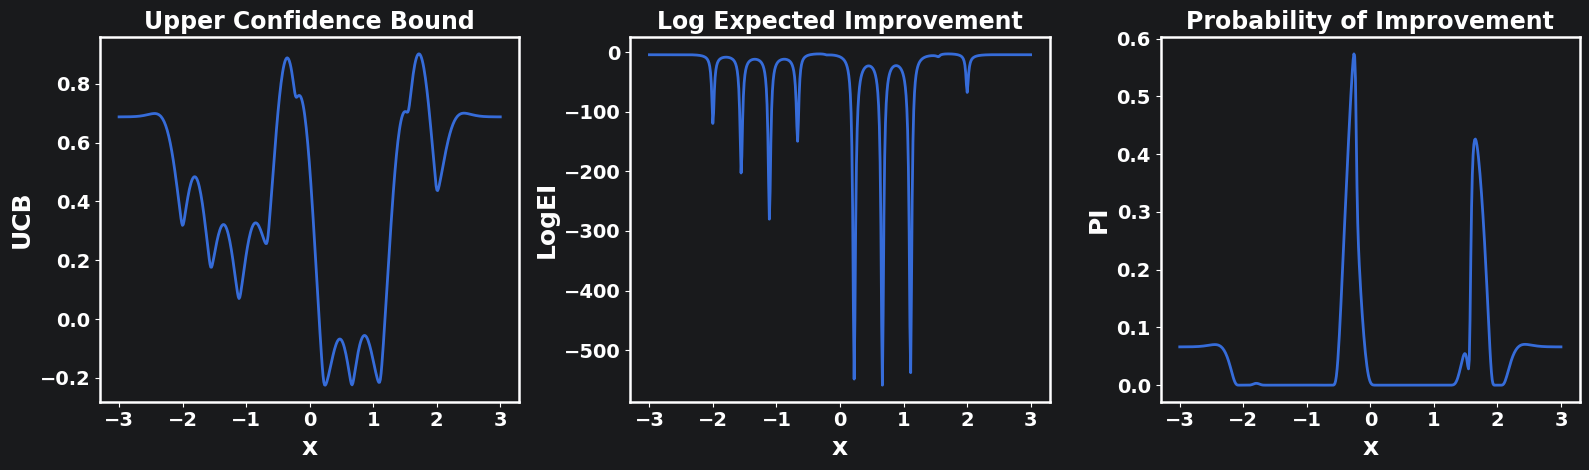

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)

axes[0].plot(x_dense.numpy(), ucb_vals.numpy(), linewidth=2.0)
axes[0].set_title("Upper Confidence Bound", fontsize=17, fontweight="bold")
axes[0].set_xlabel("x", fontsize=18, fontweight="bold")
axes[0].set_ylabel("UCB", fontsize=18, fontweight="bold")
style_ax(axes[0])

axes[1].plot(x_dense.numpy(), log_ei_vals.numpy(), linewidth=2.0)
axes[1].set_title("Log Expected Improvement", fontsize=17, fontweight="bold")
axes[1].set_xlabel("x", fontsize=18, fontweight="bold")
axes[1].set_ylabel("LogEI", fontsize=18, fontweight="bold")
style_ax(axes[1])

axes[2].plot(x_dense.numpy(), pi_vals.numpy(), linewidth=2.0)
axes[2].set_title("Probability of Improvement", fontsize=17, fontweight="bold")
axes[2].set_xlabel("x", fontsize=18, fontweight="bold")
axes[2].set_ylabel("PI", fontsize=18, fontweight="bold")
style_ax(axes[2])

plt.tight_layout()
plt.show()

## 7. Optimising the acquisition functions to choose candidate points

So far, the acquisition functions have only been **evaluated** across the dense grid and plotted as one-dimensional scoring curves.

That is useful for visual intuition, but Bayesian Optimisation ultimately needs something more concrete:

> **given an acquisition function, which point should actually be chosen next?**

This is the role of `optimize_acqf`.

Rather than just plotting the acquisition landscape, we now **optimise each acquisition function directly** over the allowed input domain and ask it to return its preferred next candidate.

---

### What the code does

The code imports `optimize_acqf` from BoTorch and uses it three times:

- once for **Log Expected Improvement**
- once for **Probability of Improvement**
- once for **Upper Confidence Bound**

Each call returns two quantities:

- the **candidate point** that optimises the acquisition function
- the **acquisition value** attained at that candidate

So the outputs

- `candidate_log_ei`
- `candidate_pi`
- `candidate_ucb`

are the actual next-point recommendations made by the three acquisition rules.

This is the first point in the notebook where the acquisition functions stop being only curves and become actual **decision rules**.

---

### What `q=1` means

The argument

```python
q=1
```

means that the acquisition function is being optimised to choose **one new candidate point**.

So this is the standard **sequential Bayesian Optimisation** setting:

- choose one point,
- evaluate the objective there,
- update the surrogate,
- and repeat.

If we instead used something like `q=3`, the optimiser would try to propose a **batch of three points jointly**.

So here, `q=1` keeps the tutorial in the simplest and most interpretable setting:

> one acquisition function → one next recommended evaluation point

---

### What `raw_samples=50` means

The argument

```python
raw_samples=50
```

controls the **initial random search stage** used before local optimisation begins.

BoTorch first generates 50 crude candidate locations across the bounded search region and evaluates the acquisition function at those rough trial points.

This serves as a scouting stage.

Its purpose is to identify promising parts of the domain from which a more serious local optimisation can be started.

So `raw_samples=50` means:

> begin with 50 rough candidate locations and use them to identify good starting regions for acquisition optimisation.

Larger values of `raw_samples` can make the optimisation more robust, especially in difficult or higher-dimensional acquisition landscapes, but they also cost more computation.

In this one-dimensional tutorial, `50` is a perfectly reasonable and robust choice.

---

### What `num_restarts=10` means

The argument

```python
num_restarts=10
```

means that, after the raw candidate screening step, BoTorch launches **10 local optimisation runs** from promising starting points.

This is important because acquisition functions are often **non-convex** and may contain:

- multiple local maxima,
- narrow peaks,
- or several distinct attractive regions.

If the optimisation were started from only one initial point, it could easily converge to a mediocre local optimum.

Using multiple restarts reduces that risk.

So `num_restarts=10` means:

> run local acquisition optimisation 10 times from different promising initial locations, and keep the best final result.

This makes the next-point selection much more reliable.

---

### Putting `q`, `raw_samples`, and `num_restarts` together

Taken together, the settings

- `q=1`
- `raw_samples=50`
- `num_restarts=10`

mean:

> choose one next candidate point, use 50 random trial locations to scout the acquisition landscape, then run 10 local optimisation attempts from promising starting points, and finally return the best result found.

So these arguments control **how the acquisition function is optimised**, not the Gaussian Process itself.

That distinction is important.

The GP defines the posterior.
The acquisition function defines the scoring rule.
And `optimize_acqf` is the procedure that numerically searches for the point that maximises that score.

---

### Why this step matters conceptually

This is one of the most important transitions in the notebook.

Earlier, the acquisition functions were only being visualised as functions over the domain.

Now they are being used in the way Bayesian Optimisation actually needs them to be used:

- not just as curves,
- but as **argmax-based decision rules**.

This is the practical meaning of an acquisition function:

> it turns the surrogate posterior into a rule for selecting the next evaluation point.

So this cell is where the notebook moves from:

- *“here is what the acquisition landscape looks like”*

to

- *“here is the actual next point that this acquisition rule recommends.”*

---

### Interpreting the printed candidate points

The printed candidate values already show something important:

- **LogEI** and **UCB** both prefer a point near `x ≈ 1.7`
- **PI** instead prefers a point near `x ≈ -0.25`

So even before plotting these selections on top of the GP surrogate, we can already see that the acquisition rules are **not identical**.

They are built from the same GP posterior, but they are not making the same decision.

This is exactly the behaviour the tutorial is meant to highlight.

---

### Why agreement and disagreement are both possible

It is worth noting that acquisition functions do **not always** choose dramatically different points.

If one region of the posterior is overwhelmingly attractive under all reasonable criteria, then several acquisition rules may agree.

So disagreement is not guaranteed.

But when the surrogate contains multiple plausible promising regions — as it does here — different decision rules can prefer different trade-offs between:

- expected gain,
- probability of success,
- and uncertainty reward.

That is what makes the candidate comparison interesting.

---

### Key takeaway

This cell uses `optimize_acqf` to turn each acquisition function into an actual **next-point recommendation**.

The arguments:

- `q=1`
- `raw_samples=50`
- `num_restarts=10`

control how that optimisation is performed, not how the GP itself is fit.

The resulting candidates show that, even when acquisition functions are built from the **same BoTorch GP surrogate**, they can still recommend different next evaluation points.

That is the practical heart of acquisition-driven Bayesian Optimisation.

In [8]:
from botorch.optim import optimize_acqf

candidate_log_ei, acq_log_ei = optimize_acqf(
    acq_function=log_ei,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=50,
)

candidate_pi, acq_pi = optimize_acqf(
    acq_function=pi,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=50,
)

candidate_ucb, acq_ucb = optimize_acqf(
    acq_function=ucb,
    bounds=bounds,
    q=1,
    num_restarts=10,
    raw_samples=50,
)

print("LogEI candidate:", candidate_log_ei.item())
print("PI candidate:", candidate_pi.item())
print("UCB candidate:", candidate_ucb.item())

LogEI candidate: 1.7037794329510072
PI candidate: -0.2549645086674675
UCB candidate: 1.719761568682357


## 8. Comparing the candidate points chosen by different acquisition functions

Now that each acquisition function has been optimised, we can place their selected candidate points back onto the **same Gaussian Process surrogate**.

This is a very important visual step.

The previous cells showed:

- the acquisition functions as abstract scoring curves,
- and the numerical candidate locations returned by `optimize_acqf`.

This figure now brings those two threads together by answering the more intuitive question:

> **where do the different acquisition rules choose to go on the GP surrogate itself?**

---

### What the code does

The figure plots the same BoTorch GP surrogate used earlier:

- the **true objective**
- the **posterior mean**
- the uncertainty band
  $$
  \mu(x)\pm 2\sigma(x)
  $$
- and the **observed training points**

It then overlays the candidate point chosen by each acquisition function:

- **LogEI** as a star
- **PI** as a square
- **UCB** as a triangle

For each selected location `x_sel`, the code finds the corresponding index on the dense grid and places the marker at the GP posterior mean value `mu_gp[idx]`.

So the markers are not being plotted at the acquisition values themselves.
They are being shown directly on the **surrogate model’s current belief about the objective**.

That is exactly what makes the comparison so interpretable.

---

### Why this figure matters

This is one of the central figures of the notebook because it shows, in a single view, that:

> **different acquisition functions can make different next-point decisions even when they are built from the same GP posterior.**

The surrogate is fixed.
The posterior mean and uncertainty band are fixed.
The observations are fixed.

What changes is only the **decision rule**:

- UCB values predicted reward plus uncertainty bonus
- LogEI values expected improvement over the current best
- PI values probability of beating the current best

So the different markers in the figure are showing **different ways of acting on the same probabilistic model**.

That is the practical heart of acquisition-function design.

---

### How to read the selected points in this figure

In this particular example, the printed optimisation results showed:

- **LogEI candidate:** `1.7037794329510072`
- **PI candidate:** `-0.2549645086674675`
- **UCB candidate:** `1.719761568682357`

So the figure reveals two important things immediately:

#### 1. LogEI and UCB are choosing the right-hand basin

Both LogEI and UCB select points near

$$
x \approx 1.7.
$$

This indicates that, according to the surrogate:

- the right-hand region looks highly attractive in expected improvement terms,
- and also remains attractive under the UCB tradeoff between value and uncertainty.

So in this example, LogEI and UCB are largely aligned.

#### 2. PI chooses a different region

PI instead selects a point near

$$
x \approx -0.25.
$$

So PI is responding differently to the surrogate.

This is exactly the sort of behaviour the tutorial is designed to demonstrate:

- same GP posterior,
- different acquisition principle,
- different next-point recommendation.

That makes the role of the acquisition function visible in a very concrete way.

---

### Why the markers are placed at the GP mean

A subtle but important detail is that the candidate markers are plotted at the **posterior mean value** `mu_gp[idx]`, not at the true objective value and not at the acquisition value.

This is the right choice for this figure, because the purpose is to show:

> where on the GP surrogate each acquisition function wants to evaluate next

rather than:

- how large the acquisition value is,
- or what the true objective happens to be there.

So the markers are shown in the model’s own predictive coordinate system.
That makes the figure a direct visualisation of the surrogate-based decision process.

---

### What this figure teaches about acquisition functions

This figure helps the reader see the acquisition rules not just as formulas, but as **policies**.

In particular, it shows that the acquisition function controls how the model’s belief is translated into action.

Even when all three rules are built from the same posterior mean and uncertainty, they may not agree because they answer different questions:

- **UCB:** where is the combination of predicted value and uncertainty most attractive?
- **LogEI:** where is the expected improvement largest?
- **PI:** where is the probability of improvement highest?

This is why Bayesian Optimisation is not determined by the GP alone.
The acquisition rule is an essential second layer.

---

### Why agreement and disagreement are both informative

It is worth noticing that the figure shows **partial agreement**, not total divergence.

That is actually useful pedagogically.

Acquisition functions do not have to disagree everywhere.
If one region of the posterior is especially attractive under multiple criteria, then several acquisition rules may select nearby points.

So the lesson of the figure is **not** that acquisition functions must always choose completely different locations.

The real lesson is:

> they **can** differ, because they encode different optimisation priorities.

In this example:

- LogEI and UCB are fairly aligned,
- but PI prefers a different basin.

That is already enough to make the conceptual point clearly.

---

### Key takeaway

This figure places the selected candidate points from LogEI, PI, and UCB directly on top of the same BoTorch GP surrogate.

It makes clear that:

- the surrogate posterior is fixed,
- but the acquisition rule changes the next-point decision.

So this is the first full visual demonstration that acquisition functions are not just mathematical score formulas — they are **different decision-making policies built on top of the same Gaussian Process model**.

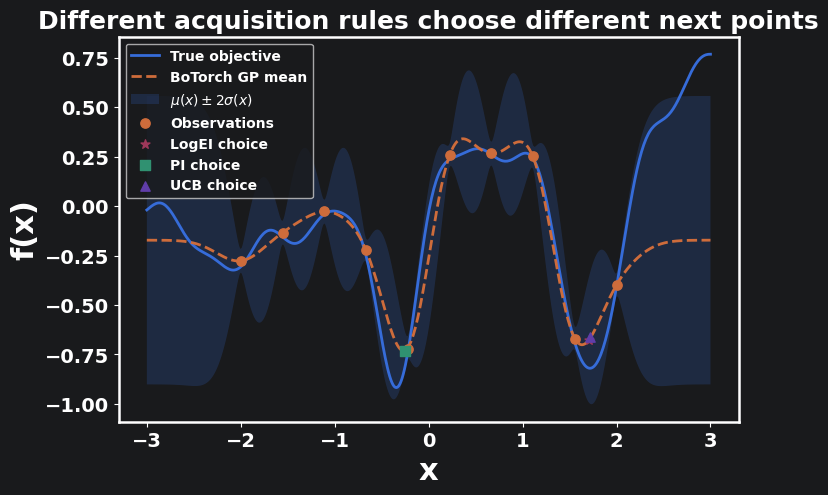

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
ax.plot(x_dense.numpy(), mu_gp.numpy(), linewidth=2.0, linestyle="--", label="BoTorch GP mean")
ax.fill_between(
    x_dense.squeeze(-1).numpy(),
    (mu_gp - 2.0 * sigma_gp).squeeze(-1).numpy(),
    (mu_gp + 2.0 * sigma_gp).squeeze(-1).numpy(),
    alpha=0.2,
    label=r"$\mu(x)\pm 2\sigma(x)$",
)
ax.scatter(train_X.numpy(), train_Y.numpy(), s=45, zorder=3, label="Observations")

for x_sel, label, marker in [
    (candidate_log_ei.item(), "LogEI choice", "*"),
    (candidate_pi.item(), "PI choice", "s"),
    (candidate_ucb.item(), "UCB choice", "^"),
]:
    idx = torch.argmin(torch.abs(x_dense.squeeze(-1) - x_sel))
    ax.scatter([x_sel], [mu_gp[idx].item()], s=45, marker=marker, zorder=4, label=label)

ax.set_title("Different acquisition rules choose different next points", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"}, loc="upper left")
style_ax(ax)
plt.show()

## 9. How different acquisition choices change the surrogate after one new observation

So far, the tutorial has shown that different acquisition functions can recommend different **next candidate points**.

But a candidate point is only meaningful because it will eventually be **evaluated**, added to the dataset, and used to update the surrogate model.

This cell takes exactly that next step.

For each acquisition rule — **UCB**, **LogEI**, and **PI** — we:

- evaluate the objective at its chosen candidate point,
- add that new observation to the training data,
- refit the Gaussian Process surrogate,
- and visualise how the posterior changes.

This is the first time in the notebook that acquisition functions are connected back to the **sequential update logic** of Bayesian Optimisation.

---

### What the code does

The dictionary

```python
choices = {"UCB": candidate_ucb, "LogEI": candidate_log_ei, "PI": candidate_pi}
```

collects the three next-point recommendations obtained from the acquisition functions.

Then, for each selected point `x_new`, the code:

1. evaluates the original objective at that point to get `y_new`
2. negates it to form `y_new_bo = -y_new`, so it remains consistent with the BoTorch maximisation convention
3. appends the new input to the existing training inputs
4. appends the new transformed target to the BoTorch training targets
5. fits a **new GP surrogate**
6. queries its posterior across the full dense grid
7. converts the mean back to the original minimisation scale with `mu_new = -posterior_new.mean.detach()`
8. extracts the updated uncertainty band

Finally, the code plots three updated surrogate views side by side:

- one after adding the **UCB-selected point**
- one after adding the **LogEI-selected point**
- one after adding the **PI-selected point**

So this figure shows the **consequence** of each acquisition decision, not just the decision itself.

---

### Why this is an important step

Up to now, acquisition functions have been treated mainly as scoring rules or next-point selectors.

But in Bayesian Optimisation, a next-point selection only matters because it changes what the model will know **after the next evaluation**.

So this cell makes the key sequential idea visible:

> different acquisition functions do not just choose different next points — they also produce different **posterior updates** after that point is observed.

This is a major conceptual step.

It shows that acquisition functions shape the future not only by choosing where to sample, but also by changing:

- which region becomes better constrained,
- where uncertainty is reduced,
- and how the posterior mean evolves after incorporating new information.

---

### Why the GP is being fitted again in each panel

This cell once again fits a fresh GP for each case, and that is intentional.

Each acquisition function produces a **different new observation**, so after adding that point, the dataset is no longer the same across the three panels.

That means each updated surrogate must be fit separately.

So the repeated fitting is not accidental or redundant.
It is necessary because we are now comparing **three distinct one-step Bayesian Optimisation futures**:

- the future that follows the UCB choice
- the future that follows the LogEI choice
- the future that follows the PI choice

Each one corresponds to a different training dataset after one additional evaluation.

---

### Why the mean is negated again after fitting

A subtle but important detail is the line

`mu_new = -posterior_new.mean.detach()`.

This is needed because the updated BoTorch GPs are still being fit to the transformed targets `-f(x)` rather than the original objective `f(x)`.

So their posterior means live in the **maximisation-oriented transformed space**.

To plot the updated surrogate on the original objective scale, we negate the mean again.

That brings the posterior back into the same visual frame as the original minimisation problem.

So the figure remains directly interpretable in terms of the original objective.

---

### How to read the three panels

Each subplot should be read as:

> “What would the GP look like after we actually evaluated the point chosen by this acquisition rule and updated the model once?”

The figure overlays:

- the **true objective**
- the **updated GP mean**
- the updated uncertainty band
- the original observations
- and the newly added point chosen by the acquisition rule

So the comparison is not only about where the rules sampled, but also about:

- how much they reduced uncertainty in different regions
- whether they improved local fit in a promising basin
- and how differently they reshape the posterior after one more evaluation

---

### What this figure teaches about acquisition functions

This figure helps make a deeper point than the earlier candidate-comparison plot.

Previously, we saw that different acquisition rules could choose different next points.

Here, we now see that those different choices lead to different **posterior evolutions**.

That is why acquisition functions matter so much in Bayesian Optimisation:

- they do not merely select a point,
- they determine what information the model receives next,
- and therefore influence the entire future trajectory of the optimisation process.

In that sense, acquisition functions are not just local decision rules.
They are mechanisms for steering the information-gathering process over time.

---

### Why this is still only a one-step demonstration

This is not yet a full Bayesian Optimisation loop.

We are only showing **one additional observation** for each acquisition function.

That is deliberate.

At this stage of the tutorial, the goal is not to run many BO iterations, but to isolate one important idea clearly:

> a different acquisition rule leads to a different next observation, and therefore to a different updated surrogate.

Once that is understood, the move to a full repeated BO loop becomes much more natural.

That full loop belongs to the next tutorial.

---

### Key takeaway

This figure shows the one-step consequence of each acquisition-function choice.

For **UCB**, **LogEI**, and **PI**, we add the selected point to the dataset, refit the surrogate, and inspect how the posterior changes.

So the cell makes visible one of the core truths of Bayesian Optimisation:

> acquisition functions do not just choose different next points — they create different future surrogates by controlling what information is gathered next.

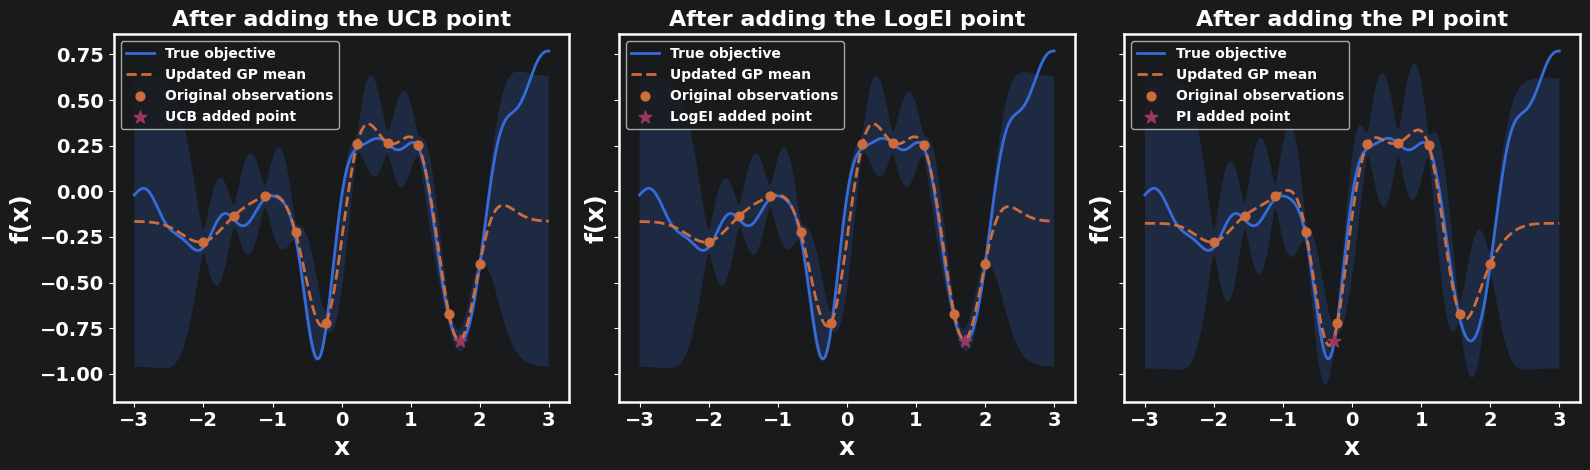

In [10]:
choices = {
    "UCB": candidate_ucb,
    "LogEI": candidate_log_ei,
    "PI": candidate_pi
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, (name, x_new) in zip(axes, choices.items()):
    y_new = objective_1d(x_new)
    y_new_bo = -y_new

    train_X_new = torch.cat([train_X, x_new])
    train_Y_new = torch.cat([train_Y_bo, y_new_bo])

    gp_new = SingleTaskGP(
        train_X=train_X_new,
        train_Y=train_Y_new,
        input_transform=Normalize(d=1),
        outcome_transform=Standardize(m=1),
    )
    mll_new = ExactMarginalLogLikelihood(gp_new.likelihood, gp_new)
    fit_gpytorch_mll(mll_new)
    gp_new.eval()

    posterior_new = gp_new.posterior(x_dense)
    mu_new = -posterior_new.mean.detach()
    sigma_new = torch.sqrt(posterior_new.variance.detach().clamp_min(1e-12))

    ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
    ax.plot(x_dense.numpy(), mu_new.numpy(), linewidth=2.0, linestyle="--", label="Updated GP mean")
    ax.fill_between(
        x_dense.squeeze(-1).numpy(),
        (mu_new - 2.0 * sigma_new).squeeze(-1).numpy(),
        (mu_new + 2.0 * sigma_new).squeeze(-1).numpy(),
        alpha=0.2,
    )
    ax.scatter(train_X.numpy(), train_Y.numpy(), s=40, zorder=3, label="Original observations")
    ax.scatter(x_new.numpy(), y_new.numpy(), s=90, marker="*", zorder=4, label=f"{name} added point")
    ax.set_title(f"After adding the {name} point", fontsize=16, fontweight="bold")
    ax.set_xlabel("x", fontsize=18, fontweight="bold")
    ax.set_ylabel("f(x)", fontsize=18, fontweight="bold")
    style_ax(ax)
    ax.legend(prop={"size": 10, "weight": "bold"}, loc="upper left")

plt.tight_layout()
plt.show()

## 10. Wrapping the acquisition workflow into a reusable function

Up to this point, the tutorial has built the standard BoTorch acquisition workflow step by step:

- fit a Gaussian Process surrogate,
- convert the problem into a BoTorch-compatible maximisation form when needed,
- define acquisition functions,
- optimise them over the domain,
- and interpret the selected candidate points.

That step-by-step construction is useful for understanding the logic.

But once the ideas are clear, it is natural to ask:

> **Can we package the whole one-step acquisition workflow into a reusable function?**

This is exactly what the next code block does.

---

### What the function does

The function `run_standard_acquisition_functions(...)` wraps the standard one-step BoTorch acquisition workflow into a single reusable procedure.

Given:

- training inputs `train_X`,
- training targets `train_Y`,
- optimisation bounds `bounds`,
- a dense plotting grid `x_dense`,
- a chosen acquisition function,
- and whether the problem is posed as **minimisation** or **maximisation**,

the function performs the full pipeline:

1. converts the observed targets into the BoTorch-compatible form
2. fits a Gaussian Process surrogate
3. evaluates the posterior on the dense grid
4. extracts the posterior mean and uncertainty
5. instantiates the requested acquisition function
6. optimises that acquisition function over the domain
7. returns the fitted surrogate information and the selected candidate point

So instead of manually repeating the whole acquisition setup every time, we can now treat it as a single reusable one-step procedure.

---

### Why the `optimisation` argument matters

A particularly useful feature of the function is that it makes the optimisation direction explicit.

If the problem is a **minimisation** problem, then the function internally negates the targets:

$$
f(x) \mapsto -f(x),
$$

so that BoTorch’s standard maximisation-oriented acquisition functions can still be used consistently.

If the problem is already a **maximisation** problem, the targets are left unchanged.

This is helpful because it makes the function more general and easier to reuse in later notebooks or experiments.

It also keeps the sign-handling logic in one place instead of scattering it throughout the notebook.

---

### What the second code block does

The second code block then **uses** the wrapper on a new observation set.

It:

- defines a new training set with 12 evenly spaced observations across `[-3, 3]`
- evaluates the objective at those points
- calls `run_standard_acquisition_functions(...)` using:
  - `acquisition_function="LogEI"`
  - `optimisation="Minimisation"`
- extracts the returned posterior mean, posterior uncertainty, and candidate point
- and plots them on top of the true objective

So this is the practical payoff of the wrapper:

> we can now run a full one-step acquisition-function workflow through a single function call and immediately visualise the result.

---

### Why this is a good closing example

This is a strong way to end the tutorial because it shows that the acquisition-function workflow is no longer tied to the exact manual sequence used earlier in the notebook.

Instead, the logic is now modular:

- input a dataset,
- choose an acquisition rule,
- and let the wrapper return the fitted surrogate and selected candidate.

That makes the acquisition pipeline feel much more like a usable tool rather than just a worked derivation.

It also prepares the ground for the next tutorial, where this kind of one-step logic will naturally be repeated inside a **full sequential Bayesian Optimisation loop**.

---

### How to read the final figure

The figure shows:

- the **true objective**
- the **BoTorch GP mean**
- the uncertainty band
  $$
  \mu(x) \pm 2\sigma(x)
  $$
- the observed training points
- and the candidate selected by the chosen acquisition function

So the final visual message is:

> once the workflow is wrapped cleanly, we can take a dataset and immediately recover both the fitted surrogate and a principled next-point recommendation.

That is exactly what acquisition functions are meant to do.

---

### Feel free to play with it

This wrapper is also meant to be **experiment-friendly**.

You can freely change things such as:

- the training inputs `train_X`
- the observed targets `train_Y`
- the optimisation direction (`"Minimisation"` or `"Maximisation"`)
- the acquisition function (`"UCB"`, `"LogEI"`, or `"PI"`)
- the UCB exploration parameter `beta`
- the search budget parameters `num_restarts` and `raw_samples`

This is actually encouraged.

Playing with the function is one of the best ways to build intuition for how acquisition rules respond to:

- different data support,
- different objective shapes,
- and different optimisation settings.

So the reader should feel free to treat this final block not just as a conclusion, but as a small experimental sandbox.

---

### Key takeaway

These two code blocks wrap the standard BoTorch acquisition workflow into a reusable one-step function and then apply it to a concrete minimisation problem.

This shows that the ideas developed earlier in the notebook are now operational:

- fit a surrogate,
- choose an acquisition rule,
- and obtain a next evaluation point through a clean reusable interface.

That is an ideal stopping point for Tutorial 2, because it naturally sets up the next question:

> **what happens when we repeat this process over many Bayesian Optimisation steps instead of just one?**

In [11]:
def run_standard_acquisition_functions(
    train_X,
    train_Y,
    bounds,
    x_dense,
    acquisition_function=None,
    optimisation=None,
    beta=2.0,
    num_restarts=10,
    raw_samples=50,
):
    if optimisation == "Minimisation":
        train_Y_bo = -train_Y
        sign = -1.0
    elif optimisation == "Maximisation":
        train_Y_bo = train_Y
        sign = 1.0
    else:
        raise ValueError("optimisation must be either 'Minimisation' or 'Maximisation'")

    y_best_bo = train_Y_bo.max().item()

    gp = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y_bo,
        input_transform=Normalize(d=train_X.shape[-1]),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    gp.eval()

    posterior = gp.posterior(x_dense)
    mu = sign * posterior.mean.detach()
    var = posterior.variance.detach().clamp_min(1e-12)
    sigma = torch.sqrt(var)

    candidates = {}
    acq_values = {}

    if acquisition_function is None or acquisition_function == "UCB":
        ucb = UpperConfidenceBound(model=gp, beta=beta)
        candidate_ucb, acq_ucb = optimize_acqf(
            acq_function=ucb,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )
        candidates["UCB"] = candidate_ucb
        acq_values["UCB"] = acq_ucb

    if acquisition_function is None or acquisition_function == "LogEI":
        log_ei = LogExpectedImprovement(model=gp, best_f=y_best_bo)
        candidate_log_ei, acq_log_ei = optimize_acqf(
            acq_function=log_ei,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )
        candidates["LogEI"] = candidate_log_ei
        acq_values["LogEI"] = acq_log_ei

    if acquisition_function is None or acquisition_function == "PI":
        pi = ProbabilityOfImprovement(model=gp, best_f=y_best_bo)
        candidate_pi, acq_pi = optimize_acqf(
            acq_function=pi,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )
        candidates["PI"] = candidate_pi
        acq_values["PI"] = acq_pi

    if acquisition_function not in [None, "UCB", "LogEI", "PI"]:
        raise ValueError("Acquisition function not recognised")

    return {
        "gp_bo": gp,
        "mu": mu,
        "sigma": sigma,
        "candidates": candidates,
        "acq_values": acq_values,
    }

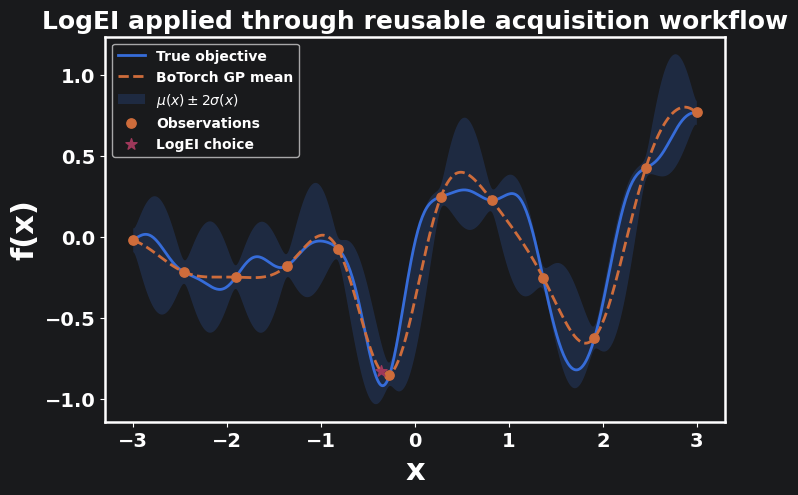

In [12]:
train_X = torch.linspace(-3, 3, 12).unsqueeze(-1)
train_Y = objective_1d(train_X)

results = run_standard_acquisition_functions(
    train_X,
    train_Y,
    bounds,
    x_dense,
    acquisition_function="LogEI",
    optimisation="Minimisation",
    num_restarts=10,
    raw_samples=50,
)

mu = results["mu"]
sigma = results["sigma"]
candidates = results["candidates"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="True objective")
ax.plot(x_dense.numpy(), mu.numpy(), linewidth=2.0, linestyle="--", label="BoTorch GP mean")
ax.fill_between(
    x_dense.squeeze(-1).numpy(),
    (mu - 2.0 * sigma).squeeze(-1).numpy(),
    (mu + 2.0 * sigma).squeeze(-1).numpy(),
    alpha=0.2,
    label=r"$\mu(x)\pm 2\sigma(x)$",
)
ax.scatter(train_X.numpy(), train_Y.numpy(), s=45, zorder=3, label="Observations")

for name, x_sel in candidates.items():
    idx = torch.argmin(torch.abs(x_dense.squeeze(-1) - x_sel.item()))
    ax.scatter([x_sel.item()], [mu[idx].item()], s=70, marker="*", zorder=4, label=f"{name} choice")

selected_name = list(candidates.keys())[0]
ax.set_title(f"{selected_name} applied through reusable acquisition workflow", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"}, loc="upper left")
style_ax(ax)
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from **surrogate modelling** to **decision making**.

The central idea was that a Gaussian Process posterior, by itself, is not yet a Bayesian Optimisation strategy.
It provides:

- a prediction of the objective through `μ(x)`,
- and a measure of uncertainty through `σ(x)`,

but it does not by itself specify where the next evaluation should be taken.

That is the role of the acquisition function.

Across the notebook, we saw how standard BoTorch acquisition rules — **UCB**, **PI**, and **LogEI** — can be:

- instantiated directly from a fitted GP surrogate,
- evaluated across the input domain,
- visualised as one-dimensional scoring curves,
- and optimised with `optimize_acqf` to produce actual candidate points.

This made a key Bayesian Optimisation principle concrete:

> the surrogate provides the posterior, but the acquisition function determines how that posterior is converted into action.

We also saw that acquisition functions built from the **same GP model** do not necessarily make the same decision.
Different rules encode different notions of what makes a point “promising”:

- **UCB** rewards value together with uncertainty,
- **PI** rewards the probability of beating the current best,
- **LogEI** rewards the expected amount of improvement in a numerically robust form.

That is why acquisition choice matters.

The one-step update comparison made this even clearer.
Different candidate points do not just produce different immediate evaluations — they lead to different **future surrogates** because they determine what information the model receives next.

So by the end of this notebook, the Bayesian Optimisation workflow is already taking shape:

1. fit a GP surrogate,
2. build an acquisition function,
3. optimise it to choose a candidate,
4. evaluate the objective,
5. update the surrogate.

The final wrapper function made this structure explicit by packaging the whole one-step acquisition workflow into a reusable procedure.

That gives us a natural stopping point:

> we now know how to carry out **one** Bayesian Optimisation decision step in BoTorch.

The next tutorial will simply ask what happens when we **repeat** that step over multiple iterations.

That is where the full sequential Bayesian Optimisation loop begins.